In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
from sklearn.preprocessing import StandardScaler

In [55]:
df = pd.read_csv("winequality-red.csv")

In [56]:
print(df.head())
print(df.info())

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  
1      9.8        5  
2      9.8        5 

In [57]:
df = df.drop_duplicates()
print(df.isnull().sum())

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


In [58]:
df['quality'] = df['quality'].apply(lambda x: 1 if x > 5 else 0)
print(df['quality'].value_counts())

quality
1    719
0    640
Name: count, dtype: int64


In [59]:
print(df['quality'].value_counts())

quality
1    719
0    640
Name: count, dtype: int64


In [60]:
X = df.drop('quality', axis=1)
y = df['quality']

In [61]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # keeps class ratio same (VERY good practice)
)

In [62]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [63]:
print(y_train.value_counts())

quality
1    575
0    512
Name: count, dtype: int64


In [64]:
baseline_model = SVC(
    kernel='rbf',
    C=1,
    gamma='scale'
)

baseline_model.fit(X_train, y_train)

baseline_preds = baseline_model.predict(X_test)

baseline_acc = accuracy_score(y_test, baseline_preds)
baseline_f1 = f1_score(y_test, baseline_preds)

print("Baseline Accuracy:", baseline_acc)
print("Baseline F1:", baseline_f1)

Baseline Accuracy: 0.7536764705882353
Baseline F1: 0.7615658362989324


In [65]:
def add_gaussian_noise(X, noise_std):
    """
    Adds Gaussian noise to feature matrix.

    noise_std = standard deviation
    Higher value -> more corruption
    """
    noise = np.random.normal(
        loc=0,
        scale=noise_std,
        size=X.shape
    )

    return X + noise

In [66]:
noise_levels = [0, 0.01, 0.05, 0.1, 0.2, 0.3, 0.5,0.6, 0.7, 0.8, 1.0]

In [67]:
accuracies = []
f1_scores = []

for noise in noise_levels:

    # Add noise
    X_train_noisy = add_gaussian_noise(X_train, noise)
    X_test_noisy = add_gaussian_noise(X_test, noise)

    # Train fresh model each time
    model = SVC(
        kernel='rbf',
        C=1,
        gamma='scale'
    )

    model.fit(X_train_noisy, y_train)

    preds = model.predict(X_test_noisy)

    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds)

    accuracies.append(acc)
    f1_scores.append(f1)

    print(f"Noise Level: {noise}")
    print(f"Accuracy: {acc:.4f} | F1: {f1:.4f}")
    print("-------------")

Noise Level: 0
Accuracy: 0.7537 | F1: 0.7616
-------------
Noise Level: 0.01
Accuracy: 0.7537 | F1: 0.7599
-------------
Noise Level: 0.05
Accuracy: 0.7500 | F1: 0.7589
-------------
Noise Level: 0.1
Accuracy: 0.7500 | F1: 0.7589
-------------
Noise Level: 0.2
Accuracy: 0.7426 | F1: 0.7552
-------------
Noise Level: 0.3
Accuracy: 0.7279 | F1: 0.7338
-------------
Noise Level: 0.5
Accuracy: 0.6949 | F1: 0.7025
-------------
Noise Level: 0.6
Accuracy: 0.6801 | F1: 0.6990
-------------
Noise Level: 0.7
Accuracy: 0.6985 | F1: 0.7092
-------------
Noise Level: 0.8
Accuracy: 0.6691 | F1: 0.6763
-------------
Noise Level: 1.0
Accuracy: 0.6765 | F1: 0.6812
-------------


In [68]:
breakdown_point = None

for noise, acc in zip(noise_levels, accuracies):
    if baseline_acc - acc > 0.08:
        breakdown_point = noise
        break

print("Model Breakdown Noise Level:", breakdown_point)

Model Breakdown Noise Level: 0.8


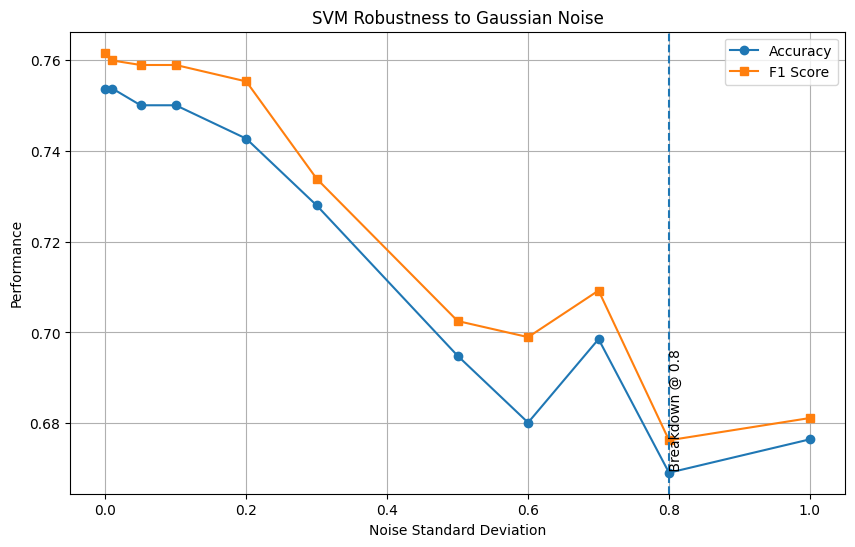

In [69]:
plt.figure(figsize=(10,6))

plt.plot(noise_levels, accuracies, marker='o', label='Accuracy')
plt.plot(noise_levels, f1_scores, marker='s', label='F1 Score')

if breakdown_point is not None:
    plt.axvline(
        x=breakdown_point,
        linestyle='--'
    )
    plt.text(
        breakdown_point,
        min(accuracies),
        f' Breakdown @ {breakdown_point}',
        rotation=90
    )

plt.xlabel("Noise Standard Deviation")
plt.ylabel("Performance")
plt.title("SVM Robustness to Gaussian Noise")

plt.legend()
plt.grid()

plt.show()